In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, preprocessing
import matplotlib.pyplot as plt

# 1. Load dataset (top 10,000 words)
max_features = 10000
maxlen = 200  # Cut off reviews after 200 words

(train_data, train_labels), (test_data, test_labels) = datasets.imdb.load_data(num_words=max_features)

# 2. Padding: Ensure all reviews are the same length (200 words)
# Reviews shorter than 200 are padded with zeros; longer ones are truncated.
train_data = preprocessing.sequence.pad_sequences(train_data, maxlen=maxlen)
test_data = preprocessing.sequence.pad_sequences(test_data, maxlen=maxlen)

print(f"Training data shape: {train_data.shape}")

17464789/17464789 [==============================] - 13s 1us/step
Training data shape: (25000, 200)


In [2]:
model = models.Sequential([
    # Embedding layer: maps word indices to 32-dimensional vectors
    layers.Embedding(max_features, 32, input_length=maxlen),

    # RNN layer: processes the sequence
    layers.SimpleRNN(32, activation='relu'),

    # Output layer: Sigmoid for binary classification (0=negative, 1=positive)
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 32)           320000    
                                                                 
 simple_rnn (SimpleRNN)      (None, 32)                2080      
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 322,113
Trainable params: 322,113
Non-trainable params: 0
_________________________________________________________________


In [3]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(train_data, train_labels,
                    epochs=5,
                    batch_size=64,
                    validation_split=0.2)

Epoch 1/5
313/313 [==============================] - 7s 19ms/step - loss: 0.5720 - accuracy: 0.6909 - val_loss: 0.4036 - val_accuracy: 0.8192
Epoch 2/5
313/313 [==============================] - 6s 19ms/step - loss: 0.3602 - accuracy: 0.8460 - val_loss: 0.4809 - val_accuracy: 0.7636
Epoch 3/5
313/313 [==============================] - 6s 19ms/step - loss: 0.2681 - accuracy: 0.8914 - val_loss: 0.3426 - val_accuracy: 0.8538
Epoch 4/5
313/313 [==============================] - 6s 19ms/step - loss: 0.2085 - accuracy: 0.9207 - val_loss: 0.3671 - val_accuracy: 0.8486
Epoch 5/5
313/313 [==============================] - 7s 21ms/step - loss: 0.2316 - accuracy: 0.9122 - val_loss: 0.4136 - val_accuracy: 0.8274


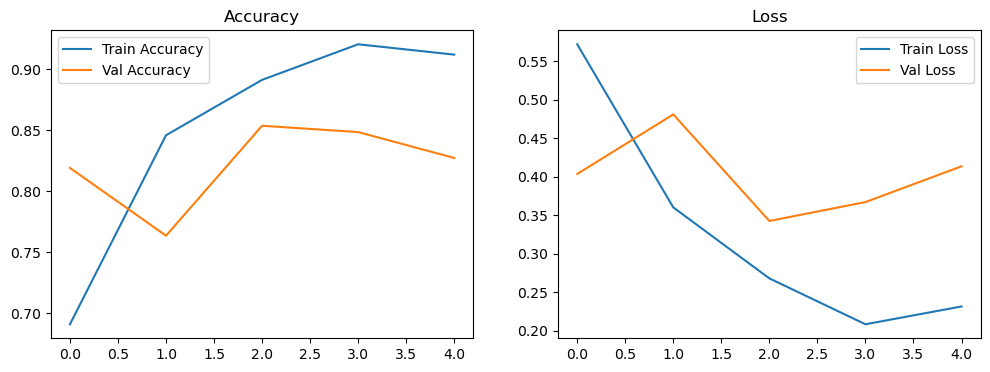

In [4]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [5]:
# Helper to encode raw text
word_index = datasets.imdb.get_word_index()

def predict_sentiment(text):
    # Tokenize the text based on the IMDB word index
    words = text.lower().split()
    tokens = [word_index.get(w, 2) + 3 for w in words] # +3 is standard for IMDB offset
    tokens = [t if t < max_features else 2 for t in tokens]

    # Pad the sequence
    padded = preprocessing.sequence.pad_sequences([tokens], maxlen=maxlen)

    # Predict
    prediction = model.predict(padded)[0][0]
    sentiment = "Positive" if prediction > 0.5 else "Negative"
    print(f"Review: '{text}'")
    print(f"Sentiment: {sentiment} (Score: {prediction:.4f})\n")

# Test examples
predict_sentiment("This movie was absolutely amazing and the acting was great")
predict_sentiment("The plot was boring and the ending was a total disappointment")

1/1 [==============================] - 0s 160ms/step
Review: 'This movie was absolutely amazing and the acting was great'
Sentiment: Negative (Score: 0.4682)

1/1 [==============================] - 0s 31ms/step
Review: 'The plot was boring and the ending was a total disappointment'
Sentiment: Negative (Score: 0.0261)

